# 01 - Jacobian construction and stability foundation

Foundation notebook for the `jacobian_analysis` project. Everything downstream
assumes the matrix conventions, normalization, and stability vocabulary
established here.

## What changes relative to the discrete-time projects

`schur_decomp`, `inhib_modulation`, and `motif_analysis` all treat the signed
connectivity matrix as a discrete state-update operator:

$$x[t+1] = M\,x[t], \qquad \text{stable} \iff \rho(M) < 1$$

This project treats the same matrix as the Jacobian of a continuous-time linear
rate model linearized about its fixed point:

$$\tau \frac{dx_i}{dt} = -x_i + \sum_j W_{ij} x_j,
\qquad J = \frac{-I + W}{\tau},
\qquad \text{stable} \iff \max_k \operatorname{Re}\lambda_k < 0$$

`W` is the same oriented, normalized `M[post, pre]` used everywhere else, so the
ablation, Schur, and motif workflows port over unchanged. What the change buys
is that a continuous-time system separates three growth rates that the discrete
spectral radius collapses into one:

| Quantity | Symbol | Answers |
|---|---|---|
| Spectral abscissa | $\alpha(J) = \max \operatorname{Re}\lambda$ | How fast does the network settle, eventually? |
| Numerical abscissa | $\omega(J) = \lambda_{\max}\!\big(\tfrac{J + J^{T}}{2}\big)$ | How fast can it grow right now, at $t = 0$? |
| Pseudospectral abscissa | $\alpha_\varepsilon(J)$ | How far can a perturbation of size $\varepsilon$ push it? |

For a normal matrix all three agree. The gap between them is transient
amplification, and it is the quantity a purely spectral analysis cannot see.

## Sections

1. Load and verify orientation
2. Normalization and gain
3. Build the Jacobian
4. Eigenvalue spectrum
5. Stability summary
6. Non-normality and the normal surrogate
7. Schur decomposition and modal coupling
8. Transient amplification
9. Pseudospectra and the Kreiss bound
10. Steady-state gain
11. E/I block structure
12. Save outputs and verify

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import jacobian_core as jc

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (7.5, 4.5), "axes.grid": True, "grid.alpha": 0.25})

MATRIX = "matrices/mij_matrix.csv"
NETLIST = "matrices/mij_netlist.csv"

# Synaptic gain. rho(W) < 1 guarantees a stable Jacobian, since eigenvalues of
# J = -I + W are those of W shifted left by one. 0.95 matches the normalization
# used in schur_decomp and inhib_modulation so results stay comparable.
GAIN = 0.95
TAU = 1.0        # membrane time constant; time is measured in units of tau
LEAK = 1.0       # coefficient on -I; leave at 1 unless testing leak sensitivity

OUT = jc.output_dir("01_jacobian_construction")
print("outputs ->", OUT)

outputs -> outputs/01_jacobian_construction


## 1. Load and verify orientation

Every `mij_matrix.csv` in this repository is stored as `M[pre, post]` and must
be transposed before use (`docs/TRANSPOSE_WARNINGS.md`). `load_jacobian_data`
transposes on load and then verifies the result rather than trusting it: E/I
identity here comes from the sign of outgoing weights, so the sign pattern of
the off-diagonal blocks is an orientation oracle. E to I entries must be
positive and I to E entries negative; the two blocks swap completely under
transposition, with 100/0 separation in this dataset. A wrong orientation raises
instead of silently reporting reversed causation.

In [2]:
data = jc.load_jacobian_data(MATRIX, NETLIST)

print(f"cell types: {data.n}")
print(f"excitatory: {len(data.excitatory)}   inhibitory: {len(data.inhibitory)}")
print()
print("orientation check (W[post, pre]):")
for key, value in data.orientation_check.items():
    print(f"  {key:22s} {value:.4f}")

masks = jc.ei_masks(data.ei, data.labels)
labels = data.labels

cell types: 85
excitatory: 32   inhibitory: 53

orientation check (W[post, pre]):
  E_to_I_positive        1.0000
  I_to_E_negative        1.0000
  n_excitatory           32.0000
  n_inhibitory           53.0000


## 2. Normalization and gain

Normalization is applied to `W`, never to `J`. Scaling `J` would rescale the
leak along with the synaptic weights, silently changing the membrane time
constant; scaling `W` changes only the synaptic gain, which is the quantity
being varied. The raw matrix has a spectral radius near $2.6 \times 10^{4}$, so
without normalization the Jacobian is wildly unstable and only structural
quantities would be meaningful.

With $\rho(W) = g < 1$ the Jacobian is guaranteed stable, because
$\lambda_J = \lambda_W - 1$ places every eigenvalue inside a disk of radius $g$
centered at $-1$. The stability margin is then at least $1 - g$.

In [3]:
norm_rows = []
for method, target in [("spectral_radius", GAIN), ("spectral_abscissa", GAIN), ("frobenius", 10.0), ("none", 1.0)]:
    _, info = jc.normalize_weights(data.W_raw, method=method, target=target)
    norm_rows.append(info)
normalization_options = pd.DataFrame(norm_rows).set_index("method")
display(normalization_options)

W, norm_info = jc.normalize_weights(data.W_raw, method="spectral_radius", target=GAIN)
print()
print(f"chosen: rho(W) = {norm_info['spectral_radius']:.4f}  (scale factor {norm_info['scale']:.3e})")
print(f"guaranteed stability margin >= {1.0 - GAIN:.3f}")

,target,scale,raw_spectral_radius,raw_spectral_abscissa,spectral_radius,spectral_abscissa,frobenius_norm
method,,,,,,,
spectral_radius,0.95,0.000036,26213.130121,26213.130121,0.950000,0.950000,7.718213e+01
spectral_abscissa,0.95,0.000036,26213.130121,26213.130121,0.950000,0.950000,7.718213e+01
frobenius,10.00,0.000005,26213.130121,26213.130121,0.123085,0.123085,1.000000e+01
none,1.00,1.000000,26213.130121,26213.130121,26213.130121,26213.130121,2.129669e+06



chosen: rho(W) = 0.9500  (scale factor 3.624e-05)
guaranteed stability margin >= 0.050


## 3. Build the Jacobian

$J = \mathrm{diag}(1/\tau)\,(-\,\text{leak}\cdot I + W)$. With scalar $\tau$
this is a pure shift of the spectrum. A non-uniform $\tau$ is a left diagonal
scaling that adds non-normality on its own, so it stays at the scalar default
here and is varied only where a notebook explicitly asks that question.

In [4]:
J = jc.build_jacobian(W, tau=TAU, leak=LEAK)
J_frame = data.frame(J)

print(f"J shape {J.shape}")
print(f"diagonal range: [{np.min(np.diag(J)):.4f}, {np.max(np.diag(J)):.4f}]")
print(f"off-diagonal nonzeros: {np.count_nonzero(J - np.diag(np.diag(J)))}")
J_frame.iloc[:5, :5]

J shape (85, 85)
diagonal range: [-1.1700, -0.3369]
off-diagonal nonzeros: 1570


,CA1 Axo Axonic,CA1 Back Projection,CA1 Basket,CA1 Basket CCK+,CA1 Bistratified
CA1 Axo Axonic,-1.0,-0.006014,-0.010149,-0.021793,-0.003752
CA1 Back Projection,0.0,-1.007116,0.000000,0.000000,-0.004581
CA1 Basket,0.0,-0.013422,-1.023773,-0.048356,-0.009492
CA1 Basket CCK+,0.0,-0.012502,-0.018572,-1.040304,-0.008742
CA1 Bistratified,0.0,-0.005641,-0.010921,-0.026975,-1.005266


## 4. Eigenvalue spectrum

Stability is now a half-plane rather than a disk. Note that the discrete
criterion and the continuous one can disagree on the same matrix: $\rho(J) > 1$
is unremarkable for a stable Jacobian, because what matters is where the
eigenvalues sit relative to the imaginary axis, not the unit circle.

,rank_by_real,real,imag,abs,decay_time_constant
0,1,-0.0500,0.0000,0.0500,20.0000
1,2,-0.6299,0.0000,0.6299,1.5875
2,3,-0.8407,0.0000,0.8407,1.1895
3,4,-0.9075,0.0000,0.9075,1.1020
4,5,-0.9513,0.0130,0.9514,1.0512
5,6,-0.9513,-0.0130,0.9514,1.0512
6,7,-0.9541,0.0000,0.9541,1.0481
7,8,-0.9717,-0.3099,1.0199,1.0291
8,9,-0.9717,0.3099,1.0199,1.0291
9,10,-0.9873,0.0000,0.9873,1.0129


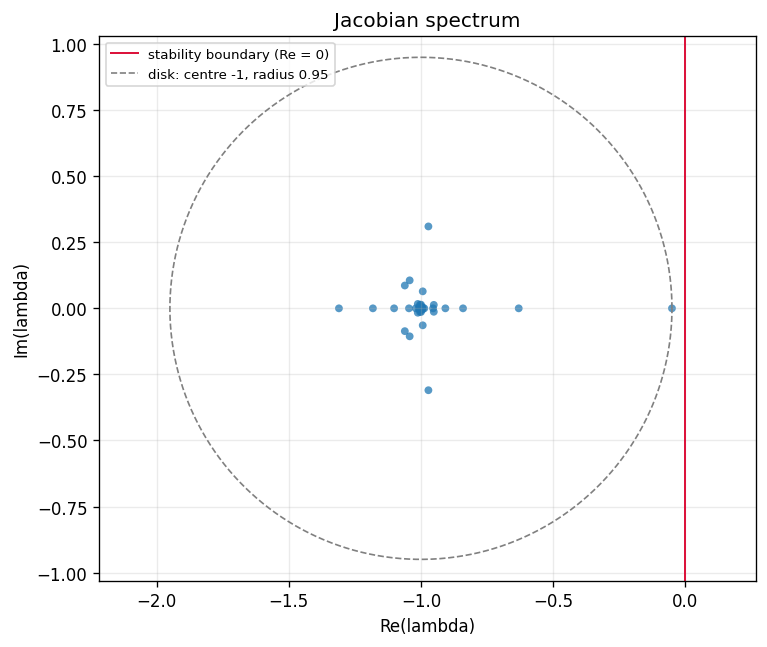

In [5]:
eigvals = np.linalg.eigvals(J)
order = np.argsort(-eigvals.real)
spectrum = pd.DataFrame({
    "rank_by_real": np.arange(1, len(eigvals) + 1),
    "real": eigvals[order].real,
    "imag": eigvals[order].imag,
    "abs": np.abs(eigvals[order]),
    "decay_time_constant": np.where(eigvals[order].real < 0, -1.0 / eigvals[order].real, np.inf),
})
display(spectrum.head(12).round(4))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(eigvals.real, eigvals.imag, s=22, alpha=0.75, edgecolor="none")
ax.axvline(0.0, color="crimson", lw=1.2, label="stability boundary (Re = 0)")
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(-1 + GAIN * np.cos(theta), GAIN * np.sin(theta), ls="--", lw=1.0, color="grey",
        label=f"disk: centre -1, radius {GAIN}")
ax.set_xlabel("Re(lambda)")
ax.set_ylabel("Im(lambda)")
ax.set_title("Jacobian spectrum")
ax.legend(loc="upper left", fontsize=8)
ax.set_aspect("equal", adjustable="datalim")
fig.tight_layout()
fig.savefig(OUT / "spectrum.png", dpi=150)
plt.show()

## 5. Stability summary

`stability_margin` is the slowest decay rate in the system: the network returns
to its fixed point no faster than $e^{-\text{margin}\,t}$. `abscissa_gap` is the
first appearance of the central result: a positive numerical abscissa alongside
a negative spectral abscissa means the network is asymptotically stable and yet
grows at $t = 0$.

In [6]:
stability = jc.stability_summary(J)
stability_table = pd.Series(stability, name="value").to_frame()
display(stability_table)

print()
if stability["amplifying_but_stable"]:
    print("Stable but amplifying: alpha = "
          f"{stability['spectral_abscissa']:.4f} < 0 < omega = {stability['numerical_abscissa']:.4f}")
    print("Eigenvalues alone predict monotone decay. They are wrong about the transient.")
else:
    print(f"alpha = {stability['spectral_abscissa']:.4f}, omega = {stability['numerical_abscissa']:.4f}")

,value
spectral_abscissa,-0.05
stability_margin,0.05
stable,True
numerical_abscissa,29.579843
abscissa_gap,29.629843
amplifying_but_stable,True
spectral_radius,1.310286
dominant_real,-0.05
dominant_imag,0.0
dominant_frequency_hz_per_tau,0.0



Stable but amplifying: alpha = -0.0500 < 0 < omega = 29.5798
Eigenvalues alone predict monotone decay. They are wrong about the transient.


## 6. Non-normality and the normal surrogate

A matrix is normal when $J J^{T} = J^{T} J$; then its eigenvectors are
orthogonal and the spectrum tells the whole story. Henrici's departure measures
what is left over: $\sqrt{\|J\|_F^2 - \sum_k |\lambda_k|^2}$, which is exactly
the Frobenius norm of the strictly upper-triangular part of the Schur form.

To make the number concrete, the **normal surrogate** is built here: a diagonal
matrix carrying the same eigenvalues as $J$ and nothing else. It has identical
asymptotic behaviour and zero transient amplification, so every difference
between $J$ and the surrogate downstream is attributable to non-normal
structure rather than to the spectrum.

In [7]:
non_normality = jc.non_normality_summary(J)
J_normal = np.real(np.diag(eigvals))  # normal surrogate: same spectrum, no coupling

comparison = pd.DataFrame({
    "jacobian": jc.non_normality_summary(J),
    "normal_surrogate": jc.non_normality_summary(J_normal),
})
display(comparison)

print()
print(f"Henrici departure: {non_normality['henrici_departure']:.3f} "
      f"({100 * non_normality['henrici_departure_relative']:.1f}% of ||J||_F)")
print(f"Eigenvector condition number: {non_normality['eigenvector_condition_number']:.3e}")
print("A large eigenvector condition number means the modal basis is far from")
print("orthogonal, so modal amplitudes can cancel and re-emerge over time.")

,jacobian,normal_surrogate
henrici_departure,77.172577,0.000000
henrici_departure_relative,0.992966,0.000000
commutator_norm,5869.903453,0.000000
eigenvector_condition_number,99205.988855,1.000000
frobenius_norm,77.719248,9.188877
spectral_norm,60.881759,1.310286
smallest_singular_value,0.002731,0.050000
condition_number,22293.131668,26.205727



Henrici departure: 77.173 (99.3% of ||J||_F)
Eigenvector condition number: 9.921e+04
A large eigenvector condition number means the modal basis is far from
orthogonal, so modal amplitudes can cancel and re-emerge over time.


## 7. Schur decomposition and modal coupling

$J = Q T Q^{*}$ with $Q$ unitary and $T$ upper triangular. The diagonal of $T$
holds the eigenvalues; the strictly upper triangle holds the feed-forward
coupling between modes that an eigendecomposition discards. Schur coordinates
are used throughout this repository because they are numerically stable for a
strongly non-normal directed matrix and keep the cascade structure visible.

Modes are ordered by real part here, so mode 1 is the slowest-decaying one. This
is the continuous-time analogue of ordering by eigenvalue magnitude in
`schur_decomp`.

reconstruction error ||Q T Q* - J||_F = 3.574e-13
modal coupling norm ||triu(T, 1)||_F  = 77.173
Henrici departure (should match)      = 77.173


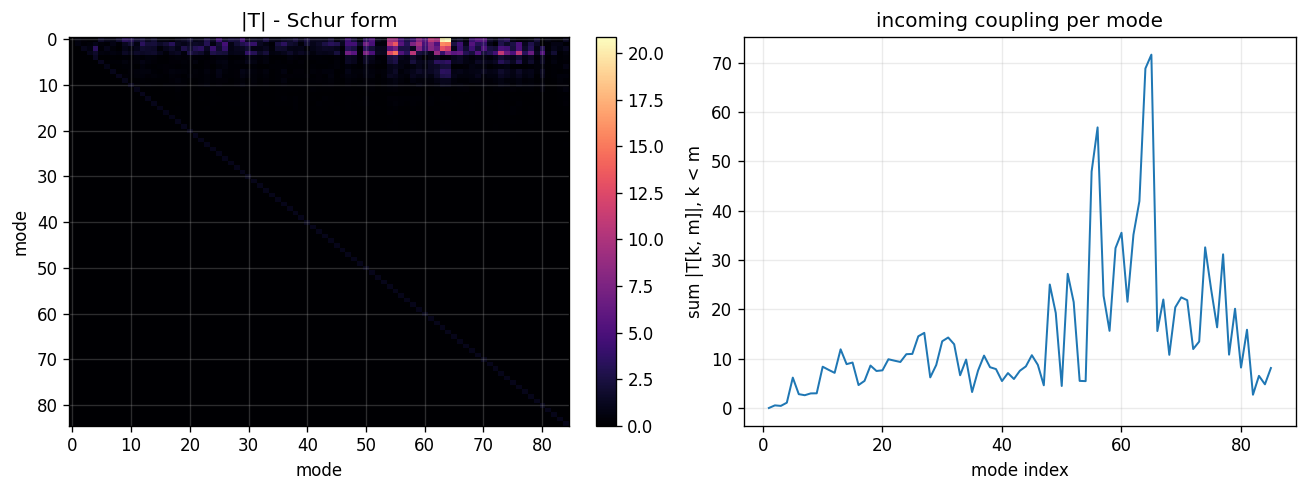

In [8]:
schur = jc.schur_decompose(J, sort="real")
print(f"reconstruction error ||Q T Q* - J||_F = {schur['reconstruction_error']:.3e}")
print(f"modal coupling norm ||triu(T, 1)||_F  = {schur['coupling_norm']:.3f}")
print(f"Henrici departure (should match)      = {non_normality['henrici_departure']:.3f}")

T = schur["T"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
im0 = axes[0].imshow(np.abs(T), cmap="magma", aspect="auto")
axes[0].set_title("|T| - Schur form")
axes[0].set_xlabel("mode")
axes[0].set_ylabel("mode")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

coupling_per_mode = np.abs(schur["coupling"]).sum(axis=0)
axes[1].plot(np.arange(1, len(coupling_per_mode) + 1), coupling_per_mode, lw=1.2)
axes[1].set_title("incoming coupling per mode")
axes[1].set_xlabel("mode index")
axes[1].set_ylabel("sum |T[k, m]|, k < m")
fig.tight_layout()
fig.savefig(OUT / "schur_coupling.png", dpi=150)
plt.show()

## 8. Transient amplification

$\|e^{Jt}\|_2$ is the largest factor by which any unit initial condition can be
amplified at time $t$. For a stable normal matrix it decays monotonically from
1. Anything above 1 is transient amplification, and it requires non-normality.

Three curves are compared: the true envelope, the eigenvalue prediction
$e^{\alpha t}$, and the normal surrogate. Where the first departs from the other
two is the part of the dynamics that the spectrum does not explain.

peak amplification 27.109x at t = 1.20 tau
normal surrogate peak 1.000x (expected 1.000)


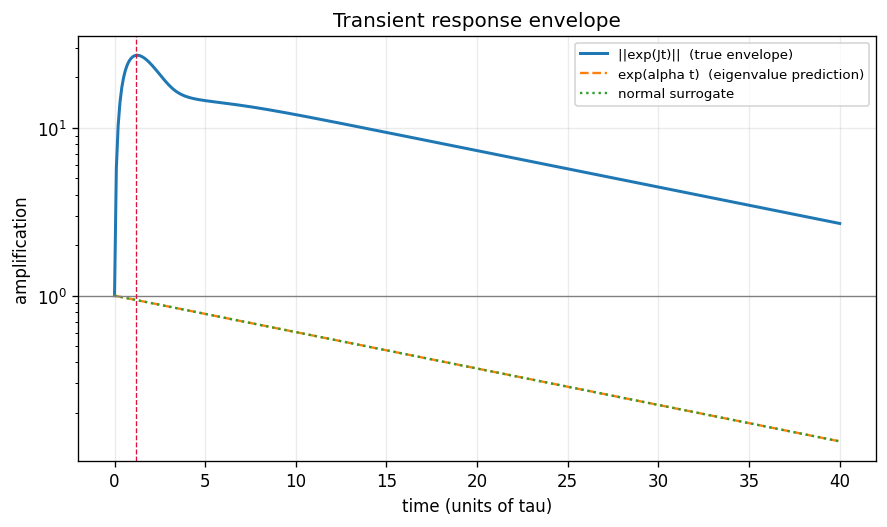

In [9]:
times = np.linspace(0.0, 40.0, 401)
envelope = jc.transient_envelope(J, times)
peak = jc.transient_peak(envelope)
surrogate_envelope = jc.transient_envelope(J_normal, times)

print(f"peak amplification {peak['peak_amplification']:.3f}x at t = {peak['time_of_peak']:.2f} tau")
print(f"normal surrogate peak {surrogate_envelope['growth'].max():.3f}x (expected 1.000)")

fig, ax = plt.subplots()
ax.plot(envelope["time"], envelope["growth"], lw=1.8, label="||exp(Jt)||  (true envelope)")
ax.plot(times, np.exp(stability["spectral_abscissa"] * times), lw=1.4, ls="--",
        label="exp(alpha t)  (eigenvalue prediction)")
ax.plot(surrogate_envelope["time"], surrogate_envelope["growth"], lw=1.4, ls=":",
        label="normal surrogate")
ax.axhline(1.0, color="grey", lw=0.8)
ax.axvline(peak["time_of_peak"], color="crimson", lw=0.8, ls="--")
ax.set_yscale("log")
ax.set_xlabel("time (units of tau)")
ax.set_ylabel("amplification")
ax.set_title("Transient response envelope")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "transient_envelope.png", dpi=150)
plt.show()

## 9. Pseudospectra and the Kreiss bound

The $\varepsilon$-pseudospectrum is the set of complex $z$ with
$\sigma_{\min}(zI - J) \le \varepsilon$: the eigenvalues reachable under a
perturbation of norm $\varepsilon$. For a normal matrix it is a union of discs
of radius $\varepsilon$ around the eigenvalues. For a non-normal one it can
bulge far past that, and when it crosses the imaginary axis the network is a
perturbation of size $\varepsilon$ away from instability even though its
eigenvalues are safely stable.

The Kreiss constant $K = \sup_\varepsilon \alpha_\varepsilon / \varepsilon$ turns
that geometry into a certificate: $\sup_t \|e^{Jt}\| \ge K$, a guaranteed lower
bound on peak amplification that needs no simulation.

,epsilon,pseudospectral_abscissa,kreiss_lower_bound
0,0.50,4.6960,9.3920
1,0.20,2.6575,13.2877
2,0.10,1.6381,16.3813
3,0.05,0.9234,18.4673
4,0.02,0.3203,16.0126
5,0.01,0.1197,11.9697


Kreiss lower bound on peak growth: 18.467
observed peak amplification:       27.109


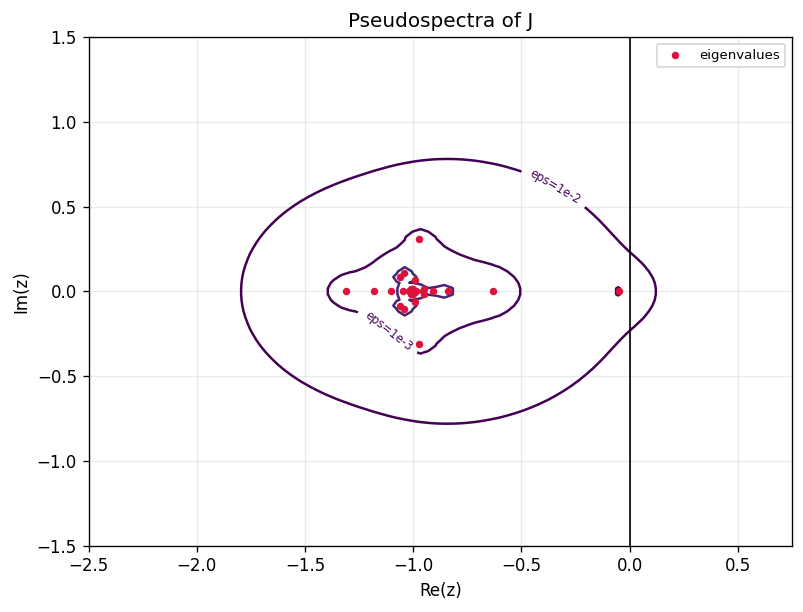

In [10]:
kreiss = jc.kreiss_constant(J, epsilons=(0.5, 0.2, 0.1, 0.05, 0.02, 0.01))
display(kreiss.round(4))

K = float(np.nanmax(kreiss["kreiss_lower_bound"]))
print(f"Kreiss lower bound on peak growth: {K:.3f}")
print(f"observed peak amplification:       {peak['peak_amplification']:.3f}")
assert peak["peak_amplification"] >= K - 1e-6, "peak growth must be at least the Kreiss bound"

# Contour plot. Reduce `resolution` if this cell is slow.
span = 1.5
re_axis, im_axis, resolvent = jc.resolvent_norm_grid(
    J, real_range=(-2.5, 0.75), imag_range=(-span, span), resolution=90
)
fig, ax = plt.subplots(figsize=(6.8, 5.2))
levels = [1e1, 1e2, 1e3, 1e4, 1e5]
contour = ax.contour(re_axis, im_axis, resolvent, levels=levels, cmap="viridis")
ax.clabel(contour, fmt=lambda v: f"eps=1e-{int(np.log10(v))}", fontsize=7)
ax.scatter(eigvals.real, eigvals.imag, s=12, color="crimson", label="eigenvalues", zorder=3)
ax.axvline(0.0, color="black", lw=1.0)
ax.set_xlabel("Re(z)")
ax.set_ylabel("Im(z)")
ax.set_title("Pseudospectra of J")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "pseudospectra.png", dpi=150)
plt.show()

## 10. Steady-state gain

For a stable Jacobian, a constant input $u$ drives the network to
$x = -J^{-1} u$. This is the continuous-time counterpart of the
$(I - M)^{-1}$ resolvent and Neumann-series machinery in `inhib_modulation`:
the same object, in coordinates where stability is a half-plane. A large DC gain
alongside a small stability margin is the standard signature of a network
operating near an instability.

In [11]:
gain = jc.steady_state_gain(J)
display(pd.Series(gain, name="value").to_frame())

R = jc.steady_state_response(J)
per_cell_gain = pd.DataFrame({
    "total_output_gain": np.abs(R).sum(axis=0),
    "total_input_gain": np.abs(R).sum(axis=1),
    "ei": [data.ei.loc[label] for label in labels],
}, index=labels)
display(per_cell_gain.sort_values("total_output_gain", ascending=False).head(10).round(3))

,value
dc_gain_spectral_norm,366.170951
dc_gain_frobenius_norm,375.159165
dc_gain_mean_abs,0.456366
dc_gain_condition_number,22293.131668


,total_output_gain,total_input_gain,ei
EC LI II Multipolar Pyramidal,1414.394,25.140,e
EC LI II Pyramidal Fan,456.801,4.002,e
CA3c Pyramidal,338.337,3.635,e
EC LII III Pyramidal Tripolar,272.345,31.326,e
CA3 Pyramidal,218.893,5.654,e
MEC LII Stellate,121.826,27.170,e
CA2 Pyramidal,64.774,14.787,e
DG Granule,58.117,9.087,e
MEC LV Pyramidal,52.404,8.862,e
MEC LIII Complex Pyramidal,38.320,19.747,e


## 11. E/I block structure

Block-level summaries of $W$, kept here so downstream ablation notebooks have a
baseline to difference against. Blocks are named source-to-target: `EI` is E
onto I, which occupies rows $I$ and columns $E$ of a `[post, pre]` matrix.

In [12]:
block_rows = []
for block in ["EE", "EI", "IE", "II"]:
    source, target = block[0].lower(), block[1].lower()
    rows = np.flatnonzero(masks[target])
    cols = np.flatnonzero(masks[source])
    sub = W[np.ix_(rows, cols)]
    nz = sub[sub != 0]
    block_rows.append({
        "block": block,
        "shape": f"{sub.shape[0]}x{sub.shape[1]}",
        "n_connections": int(nz.size),
        "density": float(nz.size / sub.size) if sub.size else np.nan,
        "mean_weight": float(nz.mean()) if nz.size else np.nan,
        "frobenius_norm": float(np.linalg.norm(sub, ord="fro")),
        "fraction_positive": float((nz > 0).mean()) if nz.size else np.nan,
    })
blocks = pd.DataFrame(block_rows).set_index("block")
display(blocks.round(4))

diag = np.diag(W)
print(f"self-connections: {int(np.count_nonzero(diag))} nonzero, "
      f"range [{diag.min():.4f}, {diag.max():.4f}]")

,shape,n_connections,density,mean_weight,frobenius_norm,fraction_positive
block,,,,,,
EE,32x32,382,0.3730,0.0787,4.9130,1.0
EI,53x32,352,0.2075,1.1657,77.0245,1.0
IE,32x53,171,0.1008,-0.0024,0.0845,0.0
II,53x53,736,0.2620,-0.0058,0.4021,0.0


self-connections: 71 nonzero, range [-0.1700, 0.6631]


## 12. Save outputs and verify

Written to `outputs/01_jacobian_construction/`. The final cell asserts the
invariants the rest of the project relies on, so a broken assumption fails here
rather than surfacing as a plausible-looking wrong number three notebooks later.

In [13]:
jc.save_table(J_frame, OUT, "jacobian_post_by_pre")
jc.save_table(data.frame(W), OUT, "weights_normalized_post_by_pre")
jc.save_table(spectrum, OUT, "eigenvalue_spectrum", index=False)
jc.save_table(stability_table, OUT, "stability_summary")
jc.save_table(comparison, OUT, "non_normality_vs_normal_surrogate")
jc.save_table(envelope, OUT, "transient_envelope", index=False)
jc.save_table(kreiss, OUT, "kreiss_bounds", index=False)
jc.save_table(blocks, OUT, "ei_block_summary")
jc.save_table(per_cell_gain, OUT, "steady_state_gain_per_cell")
jc.save_table(normalization_options, OUT, "normalization_options")
print("saved:", sorted(p.name for p in OUT.glob("*.csv")))

saved: ['ei_block_summary.csv', 'eigenvalue_spectrum.csv', 'jacobian_post_by_pre.csv', 'kreiss_bounds.csv', 'non_normality_vs_normal_surrogate.csv', 'normalization_options.csv', 'stability_summary.csv', 'steady_state_gain_per_cell.csv', 'transient_envelope.csv', 'weights_normalized_post_by_pre.csv']


In [14]:
# Verification
assert data.orientation_check["E_to_I_positive"] > 0.9, "orientation check failed"
assert data.orientation_check["I_to_E_negative"] > 0.9, "orientation check failed"
assert abs(norm_info["spectral_radius"] - GAIN) < 1e-9, "normalization did not hit its target"
assert stability["spectral_abscissa"] < 0, "J should be stable at gain < 1"
assert abs(stability["spectral_abscissa"] - (norm_info["spectral_abscissa"] - LEAK)) < 1e-8, \
    "spectrum of J must be the spectrum of W shifted left by the leak"
assert schur["reconstruction_error"] < 1e-8, "Schur reconstruction is not accurate"
assert abs(schur["coupling_norm"] - non_normality["henrici_departure"]) < 1e-6, \
    "Henrici departure must equal the norm of the strict upper triangle of T"
assert abs(envelope["growth"].iloc[0] - 1.0) < 1e-9, "||exp(J*0)|| must be exactly 1"
assert peak["peak_amplification"] >= K - 1e-6, "peak growth violates the Kreiss lower bound"
assert surrogate_envelope["growth"].max() < 1.0 + 1e-8, "the normal surrogate must not amplify"
print("all checks passed")

all checks passed


## Result

At `rho(W) = 0.95`, `tau = 1`, leak `= 1`:

| Quantity | Value | Reading |
|---|---:|---|
| Stability margin | 0.0500 | slowest decay rate; time constant 20 tau |
| Numerical abscissa | 29.58 | growth rate at t = 0 |
| Peak amplification | 27.11x at t = 1.2 tau | worst-case transient gain |
| Kreiss lower bound | 18.47 (eps = 0.05) | amplification guaranteed without simulation |
| Henrici departure | 77.17 (99.3% of ||J||_F) | distance from normal |
| Eigenvector condition number | 9.9e4 | modal basis far from orthogonal |

The network is asymptotically stable and amplifies a worst-case perturbation
27-fold before decaying. The normal surrogate, carrying the same eigenvalues and
no coupling, has peak amplification exactly 1.0, so the amplification is
attributable to non-normal structure rather than to the spectrum.

Note also that `rho(J) = 1.31`: the same matrix would be judged unstable by the
discrete-time criterion used in `schur_decomp` and `inhib_modulation`. The two
criteria are not interchangeable.

Next: `02_jacobian_schur_modes.ipynb` asks which cell types and regions carry
the amplifying modes.